In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
!pip install xgboost

In [3]:
df = pd.read_csv('heart_disease.csv')

In [4]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

In [5]:
df.sample(10)

,age,gender,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,heart_disease
3131,73,Female,Atypical Angina,139,151,True,ST-T Wave Abnormality,108,No,1.7,No
2182,33,Female,Atypical Angina,136,331,True,Normal,191,No,2.3,No
2266,70,Female,Atypical Angina,91,134,True,Normal,129,No,4.6,No
241,52,Male,Non-anginal Pain,94,269,False,Normal,169,No,4.6,Yes
2033,54,Male,Atypical Angina,171,225,False,Left Ventricular Hypertrophy,103,No,5.1,Yes
2041,78,Male,Typical Angina,163,270,True,ST-T Wave Abnormality,164,No,2.4,Yes
1127,69,Male,Atypical Angina,185,240,False,ST-T Wave Abnormality,88,Yes,1.1,Yes
3048,48,Female,Typical Angina,108,315,False,Left Ventricular Hypertrophy,84,No,1.9,No
3868,32,Male,Atypical Angina,156,283,True,Left Ventricular Hypertrophy,79,No,2.1,Yes
3481,55,Male,Non-anginal Pain,103,318,True,Left Ventricular Hypertrophy,86,Yes,3.3,Yes


In [6]:
df.shape

(4000, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      4000 non-null   int64  
 1   gender                   4000 non-null   object 
 2   chest_pain_type          4000 non-null   object 
 3   resting_blood_pressure   4000 non-null   int64  
 4   cholesterol              4000 non-null   int64  
 5   fasting_blood_sugar      4000 non-null   bool   
 6   resting_ecg              4000 non-null   object 
 7   max_heart_rate           4000 non-null   int64  
 8   exercise_induced_angina  4000 non-null   object 
 9   st_depression            4000 non-null   float64
 10  heart_disease            4000 non-null   object 
dtypes: bool(1), float64(1), int64(4), object(5)
memory usage: 316.5+ KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

age                        0
gender                     0
chest_pain_type            0
resting_blood_pressure     0
cholesterol                0
fasting_blood_sugar        0
resting_ecg                0
max_heart_rate             0
exercise_induced_angina    0
st_depression              0
heart_disease              0
dtype: int64

In [10]:
df['age'].value_counts().sum()

np.int64(4000)

In [11]:
df['gender'].isnull().sum()

np.int64(0)

In [12]:
df['gender'].value_counts()

gender
Male      2011
Female    1989
Name: count, dtype: int64

In [13]:
df.head()

,age,gender,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,heart_disease
0,67,Female,Atypical Angina,118,195,False,ST-T Wave Abnormality,112,No,1.7,No
1,57,Female,Typical Angina,155,303,True,ST-T Wave Abnormality,79,Yes,1.8,Yes
2,43,Male,Asymptomatic,105,146,False,Left Ventricular Hypertrophy,163,No,1.3,No
3,71,Female,Atypical Angina,128,285,False,Left Ventricular Hypertrophy,184,Yes,4.8,Yes
4,36,Female,Typical Angina,166,181,False,Left Ventricular Hypertrophy,196,No,2.0,No


In [14]:
df['resting_ecg'].value_counts()

resting_ecg
ST-T Wave Abnormality           1350
Left Ventricular Hypertrophy    1326
Normal                          1324
Name: count, dtype: int64

In [15]:
df['heart_disease'].isnull().sum()

np.int64(0)

In [16]:
df['resting_blood_pressure'].isnull().sum()

np.int64(0)

In [17]:
#feature engineering

In [18]:
df.head()

,age,gender,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,heart_disease
0,67,Female,Atypical Angina,118,195,False,ST-T Wave Abnormality,112,No,1.7,No
1,57,Female,Typical Angina,155,303,True,ST-T Wave Abnormality,79,Yes,1.8,Yes
2,43,Male,Asymptomatic,105,146,False,Left Ventricular Hypertrophy,163,No,1.3,No
3,71,Female,Atypical Angina,128,285,False,Left Ventricular Hypertrophy,184,Yes,4.8,Yes
4,36,Female,Typical Angina,166,181,False,Left Ventricular Hypertrophy,196,No,2.0,No


In [19]:
df['gender'] = df['gender'].map({'Male':1 ,'Female':0})

In [20]:
df['exercise_induced_angina']= df['exercise_induced_angina'].map({'Yes':1,'No':0})

In [21]:
df.head()

,age,gender,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,heart_disease
0,67,0,Atypical Angina,118,195,False,ST-T Wave Abnormality,112,0,1.7,No
1,57,0,Typical Angina,155,303,True,ST-T Wave Abnormality,79,1,1.8,Yes
2,43,1,Asymptomatic,105,146,False,Left Ventricular Hypertrophy,163,0,1.3,No
3,71,0,Atypical Angina,128,285,False,Left Ventricular Hypertrophy,184,1,4.8,Yes
4,36,0,Typical Angina,166,181,False,Left Ventricular Hypertrophy,196,0,2.0,No


In [22]:
df['heart_disease']= df['heart_disease'].map({'Yes':1,'No':0})

In [23]:
df['fasting_blood_sugar']= df['fasting_blood_sugar'].astype(int)

In [24]:
df.head()

,age,gender,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,heart_disease
0,67,0,Atypical Angina,118,195,0,ST-T Wave Abnormality,112,0,1.7,0
1,57,0,Typical Angina,155,303,1,ST-T Wave Abnormality,79,1,1.8,1
2,43,1,Asymptomatic,105,146,0,Left Ventricular Hypertrophy,163,0,1.3,0
3,71,0,Atypical Angina,128,285,0,Left Ventricular Hypertrophy,184,1,4.8,1
4,36,0,Typical Angina,166,181,0,Left Ventricular Hypertrophy,196,0,2.0,0


In [25]:
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

In [26]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [27]:
categorical_cols = ['chest_pain_type','resting_ecg']
numerical_cols = ['age','resting_blood_pressure','cholesterol','max_heart_rate','st_depression']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough' # Baaki columns (gender, etc.) ko wese hi pass kar de
)

In [30]:
pipelines = {
    "Logistic Regression": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression())
    ]),
    
    "Random Forest": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    
    "XGBoost": Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier())
    ])
}


results = []



for name, pipe in pipelines.items():
    # Pura pipeline yahan train ho raha hai (Preprocessing -> Model)
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec
    })

    print(f"✅ {name} Trained. Accuracy: {acc:.2%}")

✅ Logistic Regression Trained. Accuracy: 91.62%
✅ Random Forest Trained. Accuracy: 100.00%
✅ XGBoost Trained. Accuracy: 100.00%


In [31]:
X_train

,age,gender,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression
3994,57,1,Typical Angina,150,292,1,Normal,185,1,3.2
423,36,0,Typical Angina,187,310,1,Left Ventricular Hypertrophy,90,0,5.4
2991,51,0,Atypical Angina,176,132,0,Left Ventricular Hypertrophy,98,1,0.3
1221,33,1,Asymptomatic,160,284,1,Normal,129,1,1.7
506,33,0,Asymptomatic,148,231,1,Left Ventricular Hypertrophy,203,0,4.8
3860,57,1,Atypical Angina,190,215,0,ST-T Wave Abnormality,181,1,1.2
3563,37,1,Typical Angina,162,252,1,ST-T Wave Abnormality,139,0,0.1
1123,50,0,Asymptomatic,171,273,0,ST-T Wave Abnormality,117,0,0.9
2512,37,0,Typical Angina,133,203,0,ST-T Wave Abnormality,101,1,1.8
500,56,0,Atypical Angina,170,297,1,ST-T Wave Abnormality,151,0,3.2


In [59]:
results_df = pd.DataFrame(results)

In [60]:
print("\n--- Final Comparison Table ---")
print(results_df)


--- Final Comparison Table ---
                 Model  Accuracy  Precision    Recall
0  Logistic Regression   0.91625    0.93482  0.949477
1        Random Forest   1.00000    1.00000  1.000000
2              XGBoost   1.00000    1.00000  1.000000


C:\Users\SAEEDCOMPUTERS\AppData\Local\Temp\ipykernel_13580\1745645182.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


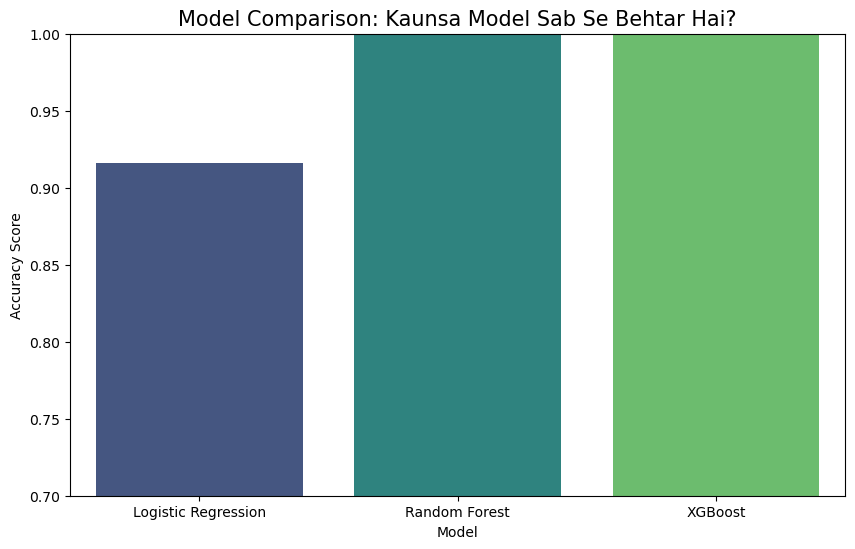

In [61]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Model Comparison: Kaunsa Model Sab Se Behtar Hai?', fontsize=15)
plt.ylim(0.7, 1.0) # Y-axis ko adjust kiya taake difference saaf dikhe
plt.ylabel('Accuracy Score')
plt.show()

In [62]:
import joblib
import pickle


In [63]:
pipeline = pipelines["Random Forest"]

In [64]:
joblib.dump(pipeline, 'heart_disease_pipeline.pkl')

['heart_disease_pipeline.pkl']

                                          **shap**

In [65]:
import shap

In [66]:
model_pipeline = joblib.load('heart_disease_pipeline.pkl')

In [67]:
# SHAP ko processed numbers chahiye hotay hain, so we use preprocessor
preprocessor = model_pipeline.named_steps['preprocessor']
classifier = model_pipeline.named_steps['classifier']

In [68]:
X_transformed = preprocessor.transform(X_train)
feature_names = preprocessor.get_feature_names_out()

In [69]:
# Clean column names (prefixes hatane ke liye)
clean_names = [name.split('__')[-1] for name in feature_names]

In [ ]:
###SHAP EXPLAINER
# Tree-based models (Random Forest/XGBoost) ke liye TreeExplainer best hai
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_transformed)

In [ ]:
#GLOBAL EXPLANATION (Ye examiner ko dikhane ke liye hai ke OVERALL model kaise sochta hai)
plt.figure(figsize=(10, 6))
print("Generating Global Summary Plot...")

In [ ]:


# 1. X_transformed ko pakka numpy array mein convert karein (agar wo sparse hai)
if hasattr(X_transformed, "toarray"):
    X_df = X_transformed.toarray()
else:
    X_df = X_transformed

# 2. Check karein ke features kitne hain
actual_num_features = X_df.shape[1]

# 3. Clean names ko utna hi rakhein jitne features hain
# Agar names kam hain to unhein poora karein, agar zyada hain to kaat dein
if len(clean_names) > actual_num_features:
    final_names = clean_names[:actual_num_features]
elif len(clean_names) < actual_num_features:
    final_names = [f"Feature {i}" for i in range(actual_num_features)]
else:
    final_names = clean_names


# Kuch models mein shap_values direct array hote hain, kuch mein list
if isinstance(shap_values, list):
    s_values = shap_values[1] # For Random Forest
else:
    s_values = shap_values # For XGBoost sometimes

# Shape match karne ke liye slice karein
s_values_final = s_values[:, :actual_num_features]

# 5. Final Plot
plt.figure(figsize=(10, 8))
print(f"Plotting with {s_values_final.shape[1]} features and {len(final_names)} names...")

shap.summary_plot(s_values_final, X_df, feature_names=final_names, show=False)

plt.savefig('shap_summary_plot.png', bbox_inches='tight', dpi=300)
plt.show()
plt.figure(figsize=(10,6))

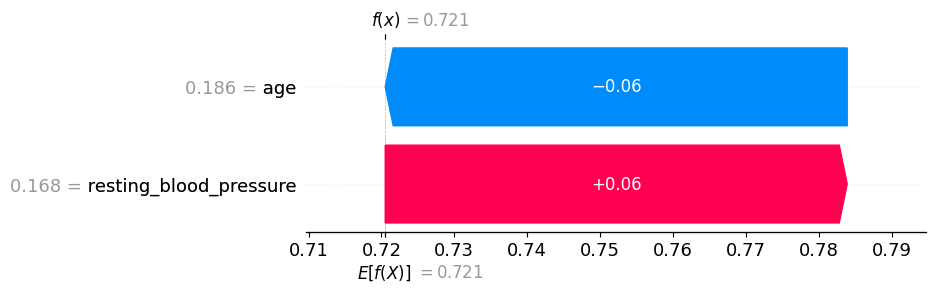

In [104]:

plt.figure(figsize=(10,6))
# 1. Explanation object banayein
# Humne values=s_values_final[0, 1] kiya hai taake sirf 'Disease' class (index 1) uthaye
exp = shap.Explanation(
    values=s_values_final[0, 1] if len(s_values_final.shape) == 3 else s_values_final[0][:, 1] if len(s_values_final[0].shape) == 2 else s_values_final[0], 
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value, 
    data=X_df[0], 
    feature_names=final_names
)

# 2. Plotting (Ab error nahi aayega)
shap.plots.waterfall(exp)

In [28]:
pip install streamlit shap joblib pandas matplotlib

  Using cached shap-0.51.0-cp313-cp313-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.51.0-cp313-cp313-win_amd64.whl (555 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [106]:
import joblib

# SHAP Explainer save karein (Website par fast reasoning ke liye)
joblib.dump(explainer, 'shap_explainer.pkl')

print("✅ Phase 2 Finalized!")
print("Files ready for Website: pipeline.pkl, df.pkl, shap_explainer.pkl, shap_summary_plot.png")

✅ Phase 2 Finalized!
Files ready for Website: pipeline.pkl, df.pkl, shap_explainer.pkl, shap_summary_plot.png
